<a href="https://colab.research.google.com/github/ryanmoraislimal96-droid/deteccao-anomalias-industriais/blob/main/Deteccao_de_Anomalias_Industriais_Projeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Detecção de Anomalias Industriais com Machine Learning

Sistema inteligente para análise de dados de sensores industriais, identificação de padrões associados a falhas e apoio à manutenção preventiva.

## 🎯 Objetivo

Desenvolver um sistema capaz de analisar leituras de sensores de equipamentos industriais e identificar comportamentos associados a possíveis falhas.

O projeto utiliza técnicas de Machine Learning, avaliação de desempenho e Inteligência Artificial Explicável (XAI) para tornar as previsões mais compreensíveis.

## 🧠 Tecnologias utilizadas

- Python
- Pandas
- Scikit-learn
- Random Forest
- Isolation Forest
- SHAP
- Matplotlib
- Gradio

## 📊 Dataset

Foi utilizado o **AI4I 2020 Predictive Maintenance Dataset**, um conjunto de dados sintético desenvolvido para representar cenários realistas de manutenção preditiva industrial.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [ ]:
# ============================================
# 2. CARREGAMENTO DO DATASET
# ============================================

!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=601)

X_original = dataset.data.features
y_original = dataset.data.targets

dados = pd.concat(
    [X_original, y_original],
    axis=1
)

print("✅ Dataset carregado com sucesso!")
print("Quantidade de registros e colunas:", dados.shape)

print(f"📊 Registros: {dados.shape[0]}")
print(f"📋 Colunas: {dados.shape[1]}")

dados.head(3).T

✅ Dataset carregado com sucesso!
Quantidade de registros e colunas: (10000, 12)
📊 Registros: 10000
📋 Colunas: 12


,0,1,2
Type,M,L,L
Air temperature,298.1,298.2,298.1
Process temperature,308.6,308.7,308.5
Rotational speed,1551,1408,1498
Torque,42.8,46.3,49.4
Tool wear,0,3,5
Machine failure,0,0,0
TWF,0,0,0
HDF,0,0,0
PWF,0,0,0


## 🔎 3. Exploração inicial dos dados

Antes do treinamento, é importante entender a distribuição das falhas no dataset.

Como falhas industriais são eventos relativamente raros, o conjunto apresenta um forte desbalanceamento entre operações normais e situações de falha.

In [ ]:
# Distribuição da variável alvo

distribuicao_falhas = dados["Machine failure"].value_counts()

total = len(dados)
normais = distribuicao_falhas[0]
falhas = distribuicao_falhas[1]

print(f"✅ Operações normais: {normais} ({normais / total * 100:.2f}%)")
print(f"⚠️ Falhas registradas: {falhas} ({falhas / total * 100:.2f}%)")

✅ Operações normais: 9661 (96.61%)
⚠️ Falhas registradas: 339 (3.39%)


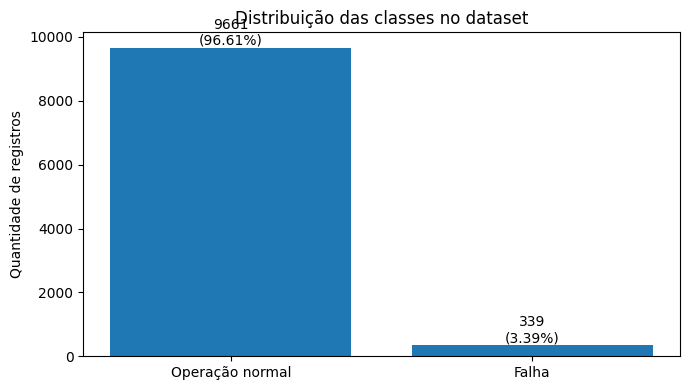

In [ ]:
# ============================================
# 3.1 VISUALIZAÇÃO DO DESBALANCEAMENTO
# ============================================

categorias = ["Operação normal", "Falha"]
quantidades = [normais, falhas]

plt.figure(figsize=(7, 4))

plt.bar(
    categorias,
    quantidades
)

plt.title("Distribuição das classes no dataset")
plt.ylabel("Quantidade de registros")

for i, valor in enumerate(quantidades):
    plt.text(
        i,
        valor,
        f"{valor}\n({valor / total * 100:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 🧪 4. Preparação dos dados

Para o treinamento dos modelos, foram selecionadas cinco variáveis numéricas relacionadas ao funcionamento do equipamento:

- Temperatura do ar
- Temperatura do processo
- Velocidade de rotação
- Torque
- Desgaste da ferramenta

A variável `Machine failure` será utilizada como alvo, indicando se houve falha no equipamento.

In [ ]:
# ============================================
# 4. SELEÇÃO DAS VARIÁVEIS
# ============================================

sensores = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

X = dados[sensores]
y = dados["Machine failure"]

print("✅ Variáveis selecionadas!")
print("Entradas:", X.shape)
print("Alvo:", y.shape)

X.head()

✅ Variáveis selecionadas!
Entradas: (10000, 5)
Alvo: (10000,)


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


### ✂️ 4.1 Divisão dos dados

O dataset foi dividido em três conjuntos independentes:

- **60% para treinamento:** utilizados para ensinar o modelo.
- **20% para validação:** utilizados para ajustar escolhas do modelo e o limite de decisão.
- **20% para teste final:** mantidos intocados até a avaliação definitiva.

A divisão utiliza estratificação para preservar a proporção de falhas em cada conjunto.

In [ ]:
# ============================================
# 4.1 TREINO, VALIDAÇÃO E TESTE
# ============================================

# Primeiro: 80% desenvolvimento e 20% teste final
X_temp, X_teste, y_temp, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Depois: dos 80%, separamos 75% treino e 25% validação
# Resultado final: 60% treino, 20% validação, 20% teste
X_train_final, X_validacao, y_train_final, y_validacao = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("✅ Divisão concluída!")
print("Treino:", len(X_train_final))
print("Validação:", len(X_validacao))
print("Teste final:", len(X_teste))

✅ Divisão concluída!
Treino: 6000
Validação: 2000
Teste final: 2000


## 🤖 5. Modelo baseline: Isolation Forest

Como primeira abordagem, foi utilizado o Isolation Forest, um algoritmo não supervisionado voltado para detecção de anomalias.

O modelo não utiliza diretamente os rótulos de falha durante o treinamento. Ele procura identificar registros que apresentam comportamentos diferentes do padrão predominante.

Essa abordagem será utilizada como baseline para comparação com o modelo supervisionado final.

In [ ]:
# ============================================
# 5. BASELINE - ISOLATION FOREST
# ============================================

modelo_baseline = IsolationForest(
    contamination=0.034,
    random_state=42
)

# O Isolation Forest recebe apenas os sensores
modelo_baseline.fit(X_train_final)

# Predição na validação
pred_baseline = modelo_baseline.predict(X_validacao)

# Isolation Forest:
#  1 = normal
# -1 = anomalia

pred_baseline_binaria = np.where(
    pred_baseline == -1,
    1,
    0
)

precision_baseline = precision_score(
    y_validacao,
    pred_baseline_binaria,
    zero_division=0
)

recall_baseline = recall_score(
    y_validacao,
    pred_baseline_binaria
)

f1_baseline = f1_score(
    y_validacao,
    pred_baseline_binaria
)

print("🤖 Resultados do Isolation Forest")
print(f"Precision: {precision_baseline * 100:.2f}%")
print(f"Recall: {recall_baseline * 100:.2f}%")
print(f"F1-score: {f1_baseline * 100:.2f}%")

🤖 Resultados do Isolation Forest
Precision: 17.28%
Recall: 20.59%
F1-score: 18.79%


## 🌲 6. Modelo supervisionado: Random Forest

Após avaliar o Isolation Forest como baseline, foi utilizada uma abordagem supervisionada com Random Forest.

Diferentemente do modelo anterior, a Random Forest utiliza os rótulos de falha durante o treinamento, permitindo aprender padrões diretamente associados à variável `Machine failure`.

Como o dataset é fortemente desbalanceado, foi utilizado `class_weight="balanced"` para aumentar a importância dos exemplos da classe minoritária durante o treinamento.

In [ ]:
# ============================================
# 6. RANDOM FOREST
# ============================================

modelo_v5 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_v5.fit(
    X_train_final,
    y_train_final
)

print("✅ Random Forest treinada com sucesso! 🌲")

✅ Random Forest treinada com sucesso! 🌲


In [ ]:
# Probabilidade de falha na validação
prob_validacao = modelo_v5.predict_proba(
    X_validacao
)[:, 1]

# Limite padrão de decisão: 50%
pred_validacao_05 = (
    prob_validacao >= 0.50
).astype(int)

precision_05 = precision_score(
    y_validacao,
    pred_validacao_05,
    zero_division=0
)

recall_05 = recall_score(
    y_validacao,
    pred_validacao_05
)

f1_05 = f1_score(
    y_validacao,
    pred_validacao_05
)

print("🌲 Random Forest - limite de 50%")
print(f"Precision: {precision_05 * 100:.2f}%")
print(f"Recall: {recall_05 * 100:.2f}%")
print(f"F1-score: {f1_05 * 100:.2f}%")

🌲 Random Forest - limite de 50%
Precision: 80.00%
Recall: 41.18%
F1-score: 54.37%


### 🎚️ 6.1 Ajuste do limite de decisão

O limite padrão de 50% apresentou alta precisão, porém baixo recall.

Como o objetivo do sistema é identificar falhas antes que elas sejam ignoradas, foram testados diferentes limites de decisão.

Reduzir o limite aumenta a sensibilidade do modelo, permitindo detectar mais falhas, embora também possa aumentar a quantidade de falsos alertas.

O limite final será escolhido utilizando o conjunto de validação, mantendo o conjunto de teste separado para a avaliação definitiva.

In [ ]:
# ============================================
# 6.1 TESTE DE DIFERENTES LIMITES
# ============================================

limites = [0.50, 0.40, 0.30, 0.20, 0.10]

resultados_limites = []

for limite in limites:

    pred = (prob_validacao >= limite).astype(int)

    precision = precision_score(
        y_validacao,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_validacao,
        pred
    )

    f1 = f1_score(
        y_validacao,
        pred
    )

    resultados_limites.append({
        "Limite": limite,
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "F1-score (%)": round(f1 * 100, 2)
    })

comparacao_limites = pd.DataFrame(resultados_limites)

comparacao_limites

,Limite,Precision (%),Recall (%),F1-score (%)
0,0.5,80.00,41.18,54.37
1,0.4,75.51,54.41,63.25
2,0.3,60.53,67.65,63.89
3,0.2,50.52,72.06,59.39
4,0.1,36.67,80.88,50.46


### 🧪 6.2 Avaliação final

Após analisar o conjunto de validação, foi escolhido um limite de decisão de 30%.

O conjunto de teste, que permaneceu separado durante o desenvolvimento, é utilizado agora para medir o desempenho final do sistema em dados não utilizados na escolha do limite.

In [ ]:
# ============================================
# 6.2 AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ============================================

limite_final = 0.30

prob_teste = modelo_v5.predict_proba(
    X_teste
)[:, 1]

pred_teste = (
    prob_teste >= limite_final
).astype(int)

precision_final = precision_score(
    y_teste,
    pred_teste,
    zero_division=0
)

recall_final = recall_score(
    y_teste,
    pred_teste
)

f1_final = f1_score(
    y_teste,
    pred_teste
)

print("🏁 RESULTADOS FINAIS")
print(f"Precision: {precision_final * 100:.2f}%")
print(f"Recall: {recall_final * 100:.2f}%")
print(f"F1-score: {f1_final * 100:.2f}%")

🏁 RESULTADOS FINAIS
Precision: 64.86%
Recall: 70.59%
F1-score: 67.61%


### 📊 6.3 Matriz de confusão

A matriz de confusão permite visualizar quantas operações normais e falhas foram classificadas corretamente ou incorretamente pelo modelo.

Ela ajuda a entender o equilíbrio entre falhas detectadas e falsos alertas.

In [14]:
# ============================================
# 6.3 MATRIZ DE CONFUSÃO FINAL
# ============================================

matriz_final = confusion_matrix(
    y_teste,
    pred_teste
)

matriz_df = pd.DataFrame(
    matriz_final,
    index=[
        "Real: Normal",
        "Real: Falha"
    ],
    columns=[
        "Previsto: Normal",
        "Previsto: Falha"
    ]
)

matriz_df

,Previsto: Normal,Previsto: Falha
Real: Normal,1906,26
Real: Falha,20,48


## 📈 7. Comparação dos modelos

Para comparar as abordagens de forma consistente, o Isolation Forest e a Random Forest são avaliados no mesmo conjunto de teste final.

A comparação utiliza Precision, Recall e F1-score, métricas mais adequadas que a acurácia para este problema devido ao forte desbalanceamento das classes.

In [15]:
# ============================================
# 7. COMPARAÇÃO FINAL DOS MODELOS
# ============================================

# Isolation Forest no conjunto de teste
pred_baseline_teste = modelo_baseline.predict(X_teste)

pred_baseline_teste_binaria = np.where(
    pred_baseline_teste == -1,
    1,
    0
)

precision_baseline_teste = precision_score(
    y_teste,
    pred_baseline_teste_binaria,
    zero_division=0
)

recall_baseline_teste = recall_score(
    y_teste,
    pred_baseline_teste_binaria
)

f1_baseline_teste = f1_score(
    y_teste,
    pred_baseline_teste_binaria
)

comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Isolation Forest",
        "Random Forest V5"
    ],

    "Precision (%)": [
        precision_baseline_teste * 100,
        precision_final * 100
    ],

    "Recall (%)": [
        recall_baseline_teste * 100,
        recall_final * 100
    ],

    "F1-score (%)": [
        f1_baseline_teste * 100,
        f1_final * 100
    ]
})

comparacao_modelos.round(2)

,Modelo,Precision (%),Recall (%),F1-score (%)
0,Isolation Forest,11.43,11.76,11.59
1,Random Forest V5,64.86,70.59,67.61


## 🧠 8. Inteligência Artificial Explicável (XAI)

Além de prever possíveis falhas, é importante compreender quais variáveis influenciam as decisões do modelo.

A Random Forest permite analisar a importância global das variáveis, enquanto o SHAP permite investigar a contribuição de cada sensor em previsões específicas.

Essa camada de explicabilidade ajuda a tornar o sistema mais transparente e interpretável.

In [16]:
# ============================================
# 8.1 IMPORTÂNCIA GLOBAL DOS SENSORES
# ============================================

importancia_global = pd.DataFrame({
    "Sensor": [
        "Temperatura do ar",
        "Temperatura do processo",
        "Rotação",
        "Torque",
        "Desgaste da ferramenta"
    ],
    "Importância (%)": modelo_v5.feature_importances_ * 100
})

importancia_global = importancia_global.sort_values(
    "Importância (%)",
    ascending=False
)

importancia_global["Importância (%)"] = (
    importancia_global["Importância (%)"].round(2)
)

importancia_global

,Sensor,Importância (%)
3,Torque,34.29
2,Rotação,29.28
4,Desgaste da ferramenta,19.66
0,Temperatura do ar,10.45
1,Temperatura do processo,6.32


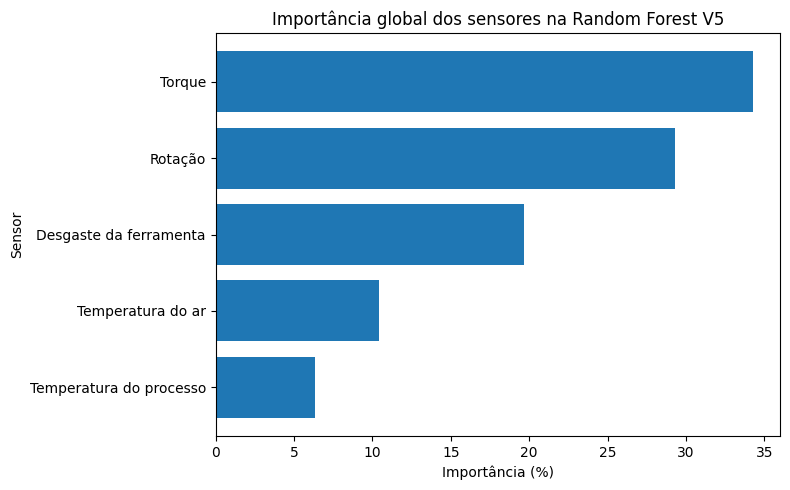

In [17]:
grafico_importancia = importancia_global.sort_values(
    "Importância (%)",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    grafico_importancia["Sensor"],
    grafico_importancia["Importância (%)"]
)

plt.xlabel("Importância (%)")
plt.ylabel("Sensor")
plt.title("Importância global dos sensores na Random Forest V5")

plt.tight_layout()
plt.show()

### 🔬 8.2 Explicação local com SHAP

A importância global mostra quais sensores são mais relevantes para o modelo de forma geral.

Para compreender uma previsão individual, será utilizado o SHAP, que estima quanto cada variável contribuiu para aumentar ou reduzir a probabilidade de falha prevista pelo modelo.

In [18]:
# ============================================
# 8.2 INSTALAÇÃO E IMPORTAÇÃO DO SHAP
# ============================================

!pip install shap -q

import shap

print("✅ SHAP instalado e importado com sucesso!")

✅ SHAP instalado e importado com sucesso!


In [19]:
# ============================================
# 8.3 ESCOLHA DE UMA PREVISÃO PARA EXPLICAR
# ============================================

# Procura casos que realmente eram falha
# E que a V5 classificou corretamente como falha

posicoes_corretas = np.where(
    (y_teste.to_numpy() == 1) &
    (pred_teste == 1)
)[0]

posicao_exemplo = posicoes_corretas[0]

entrada_explicacao = X_teste.iloc[
    [posicao_exemplo]
]

score_exemplo = prob_teste[
    posicao_exemplo
]

print("🔬 Exemplo selecionado para explicação")
print(f"Score de falha da V5: {score_exemplo * 100:.2f}%")
print()

entrada_explicacao.T

🔬 Exemplo selecionado para explicação
Score de falha da V5: 87.00%



,1391
Air temperature,298.9
Process temperature,310.2
Rotational speed,2737.0
Torque,8.8
Tool wear,142.0


In [21]:
# ============================================
# 8.4 EXPLICAÇÃO LOCAL COM SHAP
# ============================================

# Pequena amostra do treino usada como referência
background = shap.sample(
    X_train_final,
    100,
    random_state=42
)

explainer = shap.Explainer(
    modelo_v5,
    background
)

explicacao = explainer(
    entrada_explicacao
)

valores_shap = explicacao.values

# Random Forest binária pode retornar:
# [amostra, variável, classe]
if valores_shap.ndim == 3:
    contribuicoes = valores_shap[0, :, 1]
else:
    contribuicoes = valores_shap[0, :]

tabela_shap = pd.DataFrame({
    "Sensor": [
        "Temperatura do ar",
        "Temperatura do processo",
        "Rotação",
        "Torque",
        "Desgaste da ferramenta"
    ],
    "Valor": entrada_explicacao.iloc[0].values,
    "Impacto SHAP": contribuicoes * 100
})

tabela_shap["Impacto absoluto"] = (
    tabela_shap["Impacto SHAP"].abs()
)

tabela_shap = tabela_shap.sort_values(
    "Impacto absoluto",
    ascending=False
)

tabela_shap[
    ["Sensor", "Valor", "Impacto SHAP"]
].round(2)

,Sensor,Valor,Impacto SHAP
3,Torque,8.8,52.65
2,Rotação,2737.0,24.13
4,Desgaste da ferramenta,142.0,2.78
1,Temperatura do processo,310.2,2.34
0,Temperatura do ar,298.9,0.73


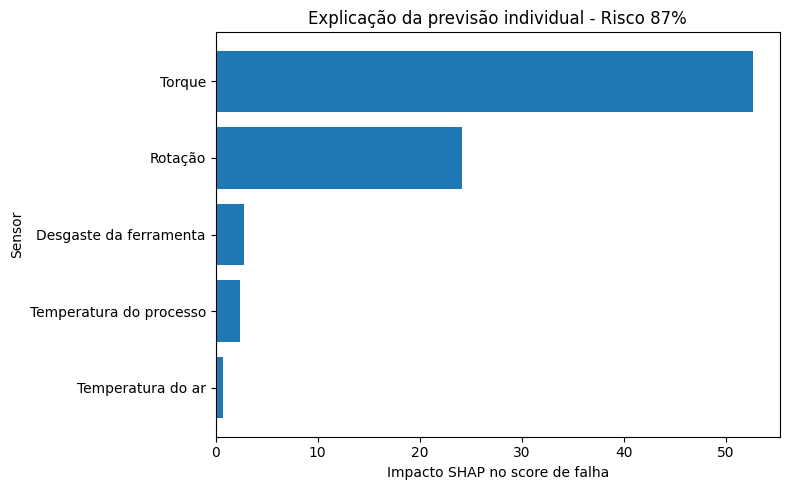

In [22]:
# ============================================
# 8.5 VISUALIZAÇÃO DA EXPLICAÇÃO LOCAL
# ============================================

grafico_shap = tabela_shap.sort_values(
    "Impacto SHAP",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    grafico_shap["Sensor"],
    grafico_shap["Impacto SHAP"]
)

plt.xlabel("Impacto SHAP no score de falha")
plt.ylabel("Sensor")
plt.title(
    f"Explicação da previsão individual - Risco {score_exemplo * 100:.0f}%"
)

plt.axvline(0)

plt.tight_layout()
plt.show()

## 🛡️ 9. Validação das leituras dos sensores

Modelos de Machine Learning podem produzir previsões mesmo quando recebem valores muito diferentes daqueles encontrados durante o treinamento.

Para reduzir esse risco, o sistema verifica se cada leitura está dentro da faixa observada nos dados de treinamento.

Caso algum sensor esteja fora desse intervalo, a previsão é bloqueada e o usuário recebe um aviso.

In [23]:
# ============================================
# 9. FAIXAS CONHECIDAS PELO MODELO
# ============================================

faixas_sensores = pd.DataFrame({
    "Sensor": [
        "Temperatura do ar",
        "Temperatura do processo",
        "Rotação",
        "Torque",
        "Desgaste da ferramenta"
    ],
    "Mínimo": X_train_final.min().values,
    "Máximo": X_train_final.max().values
})

faixas_sensores.round(2)

,Sensor,Mínimo,Máximo
0,Temperatura do ar,295.3,304.5
1,Temperatura do processo,305.7,313.8
2,Rotação,1168.0,2861.0
3,Torque,4.6,76.2
4,Desgaste da ferramenta,0.0,253.0


In [25]:
# ============================================
# 9.1 FUNÇÃO DE VALIDAÇÃO
# ============================================

def validar_sensores(
    temperatura_ar,
    temperatura_processo,
    rotacao,
    torque,
    desgaste
):
    valores = {
        "Temperatura do ar": temperatura_ar,
        "Temperatura do processo": temperatura_processo,
        "Rotação": rotacao,
        "Torque": torque,
        "Desgaste da ferramenta": desgaste
    }

    limites = {
        "Temperatura do ar": (
            X_train_final["Air temperature"].min(),
            X_train_final["Air temperature"].max()
        ),
        "Temperatura do processo": (
            X_train_final["Process temperature"].min(),
            X_train_final["Process temperature"].max()
        ),
        "Rotação": (
            X_train_final["Rotational speed"].min(),
            X_train_final["Rotational speed"].max()
        ),
        "Torque": (
            X_train_final["Torque"].min(),
            X_train_final["Torque"].max()
        ),
        "Desgaste da ferramenta": (
            X_train_final["Tool wear"].min(),
            X_train_final["Tool wear"].max()
        )
    }

    problemas = []

    for sensor, valor in valores.items():
        minimo, maximo = limites[sensor]

        if valor < minimo or valor > maximo:
            problemas.append(
                f"{sensor}: {valor} fora da faixa "
                f"({minimo:.1f} a {maximo:.1f})"
            )

    return problemas

In [26]:
teste_protecao = validar_sensores(
    300,
    310,
    50000,
    40,
    100
)

print("🛡️ Teste da proteção:")
print("\n".join(teste_protecao))

🛡️ Teste da proteção:
Rotação: 50000 fora da faixa (1168.0 a 2861.0)


## 🖥️ 10. Sistema interativo

Para transformar o modelo em uma aplicação utilizável, foi desenvolvida uma interface interativa.

O usuário pode inserir as leituras dos cinco sensores e receber:

- classificação do equipamento;
- score de risco;
- nível de risco;
- recomendação;
- validação das leituras;
- explicação dos principais fatores da decisão.

In [27]:
# ============================================
# 10.1 FUNÇÃO PRINCIPAL DO SISTEMA
# ============================================

def analisar_sistema(
    temperatura_ar,
    temperatura_processo,
    rotacao,
    torque,
    desgaste
):

    # ----------------------------------------
    # 1. Validação das leituras
    # ----------------------------------------

    problemas = validar_sensores(
        temperatura_ar,
        temperatura_processo,
        rotacao,
        torque,
        desgaste
    )

    tabela_leituras = pd.DataFrame({
        "Sensor": [
            "Temperatura do ar",
            "Temperatura do processo",
            "Rotação",
            "Torque",
            "Desgaste da ferramenta"
        ],
        "Valor": [
            temperatura_ar,
            temperatura_processo,
            rotacao,
            torque,
            desgaste
        ]
    })

    if problemas:

        mensagem = """
# 🛑 ANÁLISE NÃO REALIZADA

Um ou mais sensores estão fora da faixa conhecida pelo modelo.

"""

        mensagem += "\n\n".join(
            [f"⚠️ {problema}" for problema in problemas]
        )

        mensagem += """

### Recomendação

Verifique as leituras dos sensores antes de realizar uma nova análise.
"""

        return mensagem, tabela_leituras, None, ""

    # ----------------------------------------
    # 2. Preparação da entrada
    # ----------------------------------------

    entrada = pd.DataFrame(
        [[
            temperatura_ar,
            temperatura_processo,
            rotacao,
            torque,
            desgaste
        ]],
        columns=sensores
    )

    # ----------------------------------------
    # 3. Score de falha
    # ----------------------------------------

    score = modelo_v5.predict_proba(
        entrada
    )[0, 1]

    # ----------------------------------------
    # 4. Classificação
    # ----------------------------------------

    if score < 0.30:

        nivel = "🟢 BAIXO"
        status = "✅ OPERAÇÃO NORMAL"

        recomendacao = (
            "Nenhuma anomalia relevante foi identificada. "
            "Mantenha o monitoramento normal do equipamento."
        )

    elif score < 0.50:

        nivel = "🟡 ATENÇÃO"
        status = "⚠️ ANOMALIA DETECTADA"

        recomendacao = (
            "Recomendada verificação preventiva das leituras "
            "e acompanhamento do equipamento."
        )

    elif score < 0.70:

        nivel = "🟠 ALTO"
        status = "⚠️ ANOMALIA DETECTADA"

        recomendacao = (
            "Recomendada avaliação da equipe de manutenção."
        )

    else:

        nivel = "🔴 CRÍTICO"
        status = "🚨 ANOMALIA DETECTADA"

        recomendacao = (
            "Recomendada avaliação prioritária "
            "pela equipe de manutenção."
        )

    resultado = f"""
# {status}

### Nível de risco: {nivel}

**Score do modelo: {score * 100:.2f}%**

### 🔧 Recomendação

{recomendacao}
"""

    # ----------------------------------------
    # 5. Explicação SHAP
    # ----------------------------------------

    explicacao_local = explainer(entrada)

    valores = explicacao_local.values

    if valores.ndim == 3:
        contribuicoes = valores[0, :, 1]
    else:
        contribuicoes = valores[0, :]

    nomes_pt = [
        "Temperatura do ar",
        "Temperatura do processo",
        "Rotação",
        "Torque",
        "Desgaste da ferramenta"
    ]

    df_shap = pd.DataFrame({
        "Sensor": nomes_pt,
        "Impacto SHAP": contribuicoes * 100
    })

    df_shap["Impacto absoluto"] = (
        df_shap["Impacto SHAP"].abs()
    )

    df_shap = df_shap.sort_values(
        "Impacto absoluto",
        ascending=False
    )

    # ----------------------------------------
    # 6. Texto explicativo
    # ----------------------------------------

    texto_explicacao = "## 🧠 Principais fatores desta decisão\n\n"

    for _, linha in df_shap.head(3).iterrows():

        impacto = linha["Impacto SHAP"]

        if impacto >= 0:
            efeito = "⬆️ aumentou o score de falha"
        else:
            efeito = "⬇️ reduziu o score de falha"

        texto_explicacao += (
            f"**{linha['Sensor']}**: "
            f"{impacto:+.2f} pontos • {efeito}\n\n"
        )

    # ----------------------------------------
    # 7. Gráfico local
    # ----------------------------------------

    grafico = df_shap.sort_values(
        "Impacto SHAP",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        grafico["Sensor"],
        grafico["Impacto SHAP"]
    )

    ax.axvline(0)

    ax.set_xlabel(
        "Impacto SHAP no score de falha"
    )

    ax.set_title(
        f"Explicação da previsão - Risco {score * 100:.0f}%"
    )

    plt.tight_layout()

    return (
        resultado,
        tabela_leituras,
        fig,
        texto_explicacao
    )


# 🚨 ANOMALIA DETECTADA

### Nível de risco: 🔴 CRÍTICO

**Score do modelo: 87.00%**

### 🔧 Recomendação

Recomendada avaliação prioritária pela equipe de manutenção.

## 🧠 Principais fatores desta decisão

**Torque**: +52.65 pontos • ⬆️ aumentou o score de falha

**Rotação**: +24.13 pontos • ⬆️ aumentou o score de falha

**Desgaste da ferramenta**: +2.78 pontos • ⬆️ aumentou o score de falha




,Sensor,Valor
0,Temperatura do ar,298.9
1,Temperatura do processo,310.2
2,Rotação,2737.0
3,Torque,8.8
4,Desgaste da ferramenta,142.0


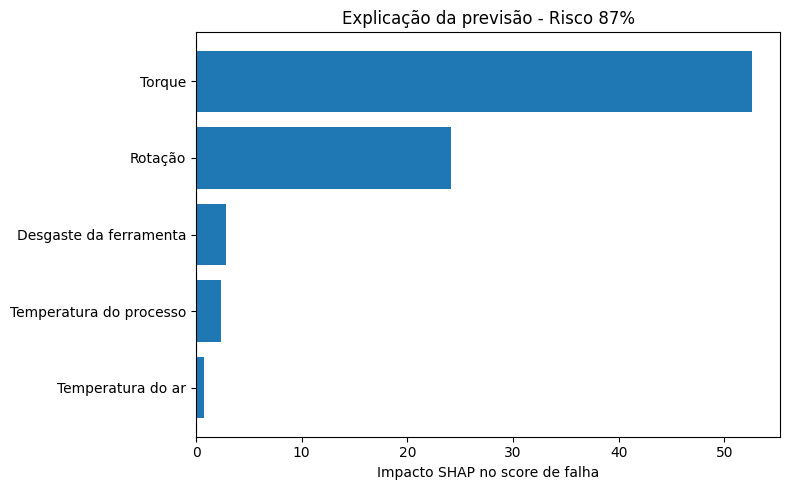

In [28]:
resultado_teste = analisar_sistema(
    298.9,
    310.2,
    2737,
    8.8,
    142
)

print(resultado_teste[0])
print(resultado_teste[3])

resultado_teste[1]

### 🖥️ 10.2 Dashboard interativo

A interface abaixo permite utilizar o sistema diretamente pelo navegador.

Após inserir as leituras dos sensores, o sistema valida os dados, calcula o risco de falha e apresenta uma explicação da decisão.

In [29]:
# ============================================
# 10.2 DASHBOARD FINAL COM GRADIO
# ============================================

!pip install gradio -q

import gradio as gr

with gr.Blocks(
    title="Detecção de Anomalias Industriais"
) as app:

    gr.Markdown(
        """
# 🏭 Sistema de Detecção de Anomalias Industriais

### 🌲 Random Forest V5 + 🧠 SHAP + 🛡️ Validação de sensores

Insira as leituras do equipamento para realizar uma análise.

**Limite de detecção:** 30%
"""
    )

    with gr.Column():

        temperatura_ar = gr.Number(
            label="🌡️ Temperatura do ar (K)"
        )

        temperatura_processo = gr.Number(
            label="🔥 Temperatura do processo (K)"
        )

        rotacao = gr.Number(
            label="⚙️ Rotação (RPM)"
        )

        torque = gr.Number(
            label="🔩 Torque (Nm)"
        )

        desgaste = gr.Number(
            label="🛠️ Desgaste da ferramenta (min)"
        )

        botao_analisar = gr.Button(
            "🔍 Analisar equipamento",
            variant="primary"
        )

    resultado = gr.Markdown()

    tabela = gr.Dataframe(
        label="📊 Leituras analisadas",
        interactive=False
    )

    explicacao = gr.Markdown()

    grafico = gr.Plot(
        label="🧠 Explicação da decisão"
    )

    botao_analisar.click(
        fn=analisar_sistema,
        inputs=[
            temperatura_ar,
            temperatura_processo,
            rotacao,
            torque,
            desgaste
        ],
        outputs=[
            resultado,
            tabela,
            grafico,
            explicacao
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db7c320b94677c7bd2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [30]:
# ============================================
# 11. PACOTE FINAL DO MODELO
# ============================================

import joblib

pacote_final = {
    "modelo": modelo_v5,
    "limite": limite_final,
    "sensores": sensores,

    "faixas": {
        sensor: {
            "minimo": float(X_train_final[sensor].min()),
            "maximo": float(X_train_final[sensor].max())
        }
        for sensor in sensores
    },

    "metricas_teste": {
        "precision": float(precision_final),
        "recall": float(recall_final),
        "f1_score": float(f1_final)
    }
}

joblib.dump(
    pacote_final,
    "modelo_anomalias_industriais_v5.pkl"
)

print("✅ Pacote final criado com sucesso!")

✅ Pacote final criado com sucesso!


In [31]:
# ============================================
# 11.1 SALVAR PACOTE FINAL NO GOOGLE DRIVE
# ============================================

from google.colab import drive
import os
import joblib

drive.mount("/content/drive")

pasta_projeto = "/content/drive/MyDrive/projeto_anomalias_industriais"

os.makedirs(
    pasta_projeto,
    exist_ok=True
)

caminho_modelo = os.path.join(
    pasta_projeto,
    "modelo_anomalias_industriais_v5.pkl"
)

joblib.dump(
    pacote_final,
    caminho_modelo
)

print("✅ Modelo V5 salvo permanentemente no Google Drive!")
print("📁 Local:", caminho_modelo)

Mounted at /content/drive
✅ Modelo V5 salvo permanentemente no Google Drive!
📁 Local: /content/drive/MyDrive/projeto_anomalias_industriais/modelo_anomalias_industriais_v5.pkl


# ✅ Conclusão

Este projeto desenvolveu um sistema de detecção de anomalias industriais utilizando técnicas de Machine Learning aplicadas a dados de sensores.

Durante o desenvolvimento, uma abordagem não supervisionada com Isolation Forest foi utilizada como baseline. Posteriormente, uma Random Forest supervisionada apresentou desempenho significativamente superior na identificação das falhas reais.

O modelo final utilizou um limite de decisão de 30%, escolhido a partir do conjunto de validação para equilibrar a capacidade de detectar falhas e a quantidade de falsos alertas.

## 📊 Resultados finais

- **Precision:** 64,86%
- **Recall:** 70,59%
- **F1-score:** 67,61%

No conjunto de teste final, o modelo:

- detectou corretamente **48 falhas reais**;
- deixou de detectar **20 falhas**;
- gerou **26 falsos alertas**;
- classificou corretamente **1.906 operações normais**.

## 🧠 Explicabilidade

Foi utilizado SHAP para interpretar previsões individuais e identificar quais sensores contribuíram para cada decisão.

Também foi analisada a importância global das variáveis, com Torque e Rotação apresentando maior influência sobre as decisões da Random Forest.

## 🛡️ Segurança das entradas

O sistema possui validação das leituras dos sensores e bloqueia previsões quando recebe valores fora das faixas observadas durante o treinamento.

Isso evita que o modelo gere resultados aparentemente confiáveis para condições que não conhece.

## 🖥️ Aplicação

Uma interface interativa foi construída com Gradio, permitindo:

- inserir leituras dos sensores;
- calcular o risco de falha;
- classificar o nível de risco;
- receber recomendações de manutenção;
- visualizar as leituras analisadas;
- compreender os principais fatores da decisão através do SHAP.

## 🚀 Possíveis melhorias futuras

Como evolução do projeto, podem ser explorados:

- novos algoritmos de classificação;
- otimização de hiperparâmetros;
- engenharia de novas variáveis;
- validação com dados industriais reais;
- criação de uma API;
- implantação permanente em nuvem;
- desenvolvimento de uma futura versão V6.